# Flight Fare Prediction
### PRCP-1025 | Regression Project | Domain: Aviation

**Objective:** Predict flight ticket prices based on features 
like airline, source, destination, duration and stops.

**Tasks:**
- Task 1: Complete Data Analysis Report
- Task 2: Build a predictive model to predict flight prices


---

## 1.Data Loading & Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Flight_Fare.xlsx')
df.shape

(10683, 11)

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


**Observations:**
- Dataset has 10,683 rows and 11 columns
- Almost all features are string/object type — heavy 
  feature engineering will be required
- Route and Total_Stops each have 1 missing value — 
  will be handled in preprocessing
- Price ranges from 1,759 to 79,512 INR — very wide range
- Max price of 79,512 is far from 75th percentile of 12,373 
  — suggests outliers in price
- Only Price column is numeric — all others need encoding

## 2.Exploratory Data Analysis

#### Price Distribution

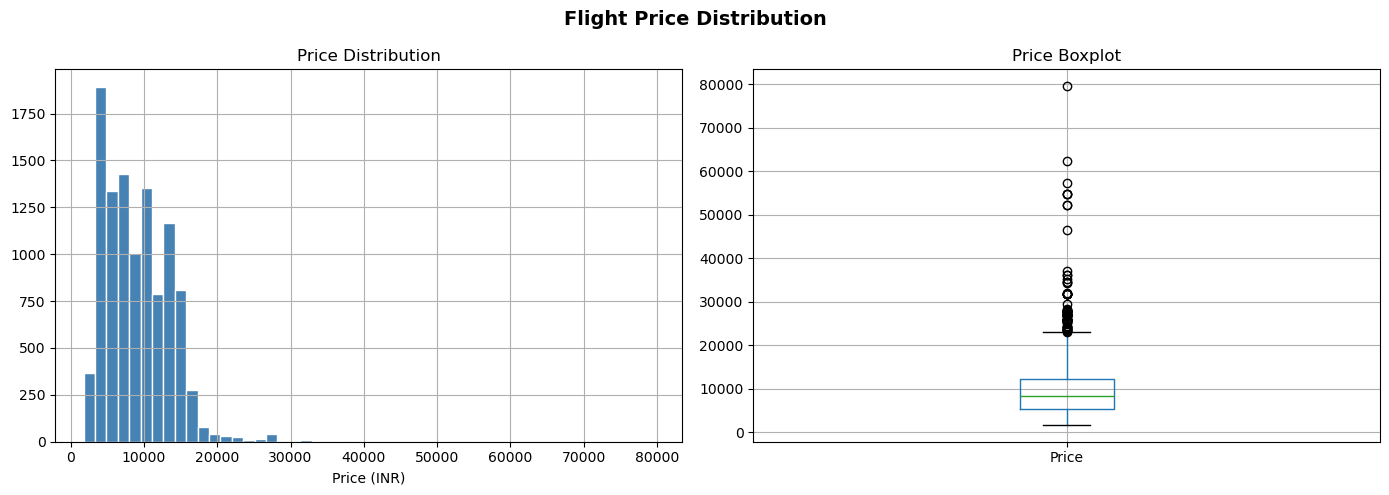

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Price'].hist(bins=50, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (INR)')

df.boxplot(column='Price', ax=axes[1])
axes[1].set_title('Price Boxplot')

plt.suptitle('Flight Price Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Airline vs Price

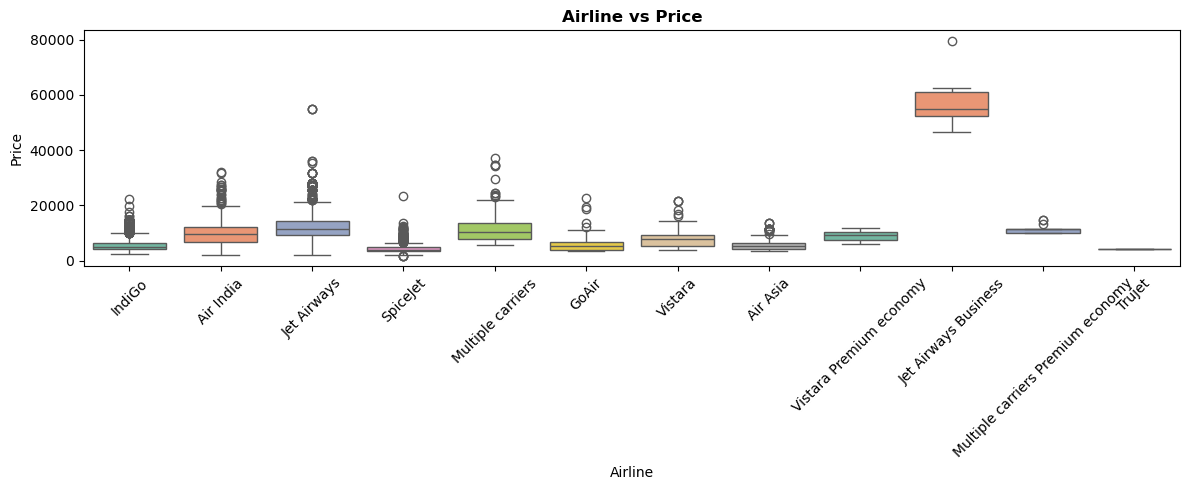

In [9]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Airline', y='Price', hue='Airline', 
            palette='Set2', legend=False)
plt.title('Airline vs Price', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Total Stops vs Price

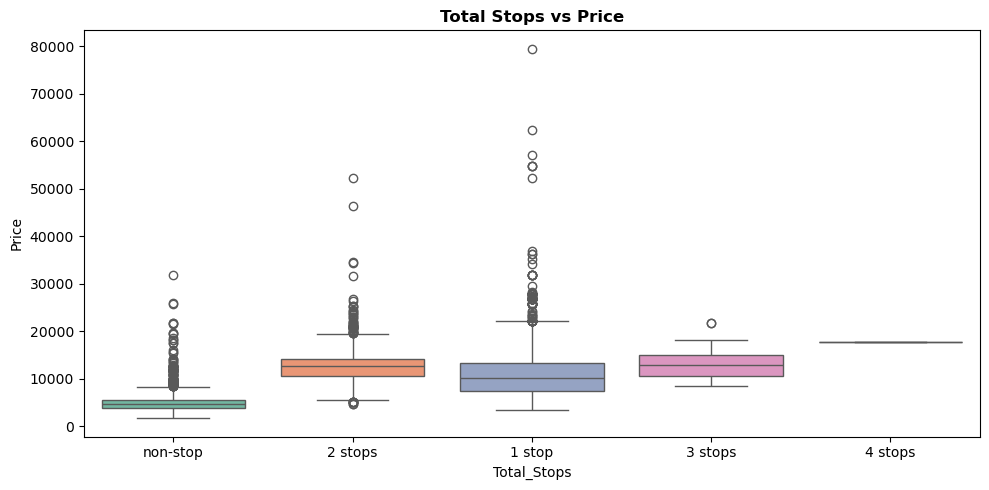

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Total_Stops', y='Price', 
            hue='Total_Stops', palette='Set2', legend=False)
plt.title('Total Stops vs Price', fontweight='bold')
plt.tight_layout()
plt.show()

####  Source vs Price

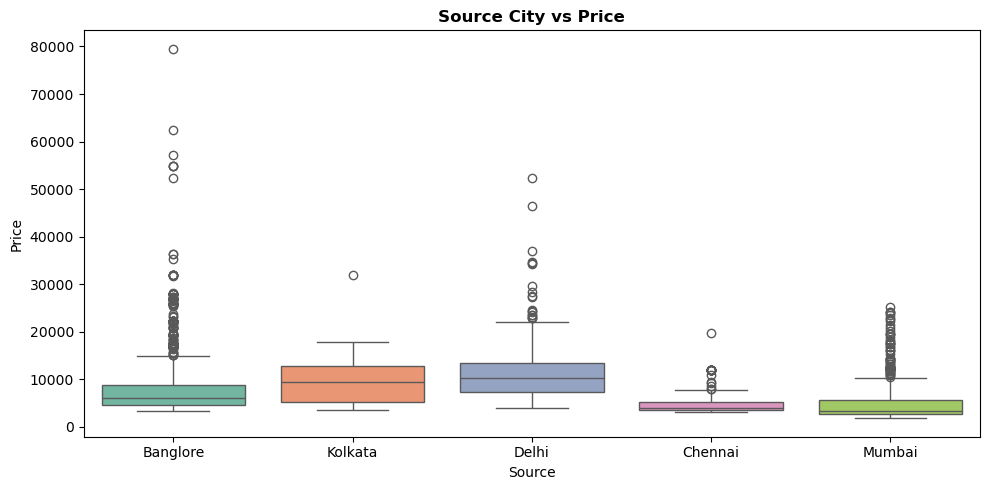

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Source', y='Price',
            hue='Source', palette='Set2', legend=False)
plt.title('Source City vs Price', fontweight='bold')
plt.tight_layout()
plt.show()

#### Destination vs Price

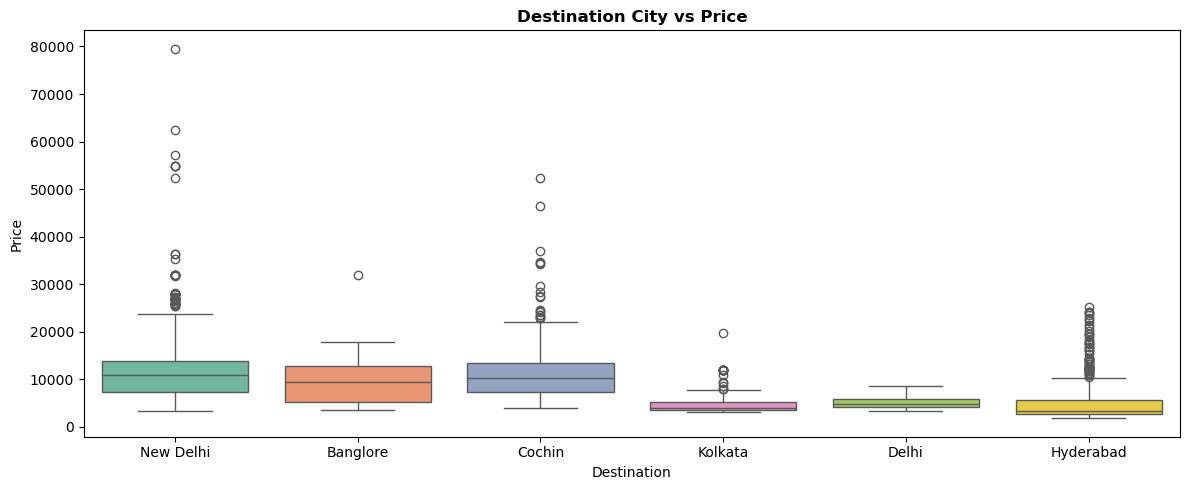

In [12]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Destination', y='Price',
            hue='Destination', palette='Set2', legend=False)
plt.title('Destination City vs Price', fontweight='bold')
plt.tight_layout()
plt.show()

#### Airline flight count

In [13]:
df['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

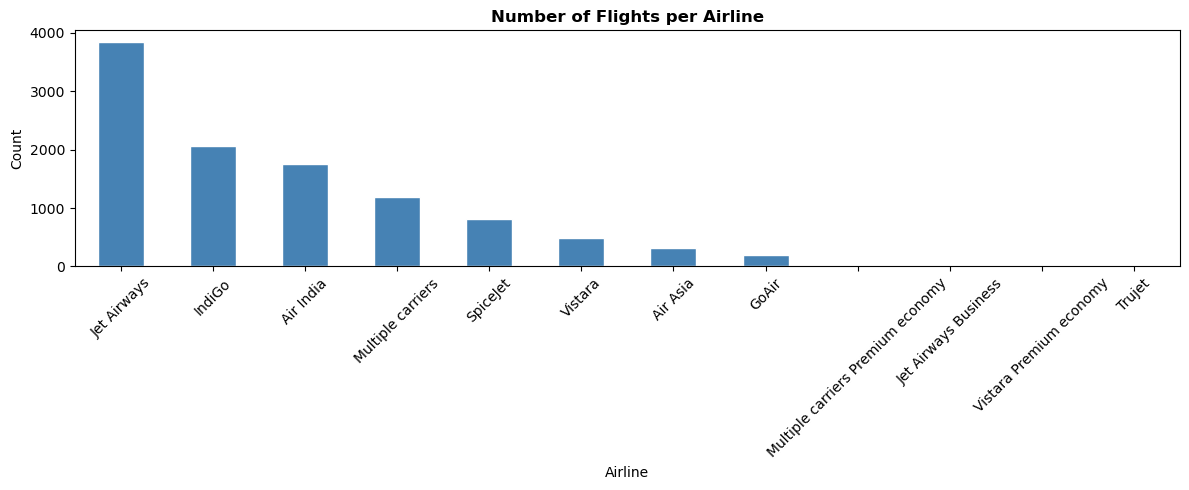

In [14]:
plt.figure(figsize=(12, 5))
df['Airline'].value_counts().plot(kind='bar', color='steelblue', 
                                   edgecolor='white')
plt.title('Number of Flights per Airline', fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations:**

**Price Distribution:**
- Price is right skewed — most flights are between 
  5,000 and 15,000 INR
- Mean price is 9,087 INR with max of 79,512 INR
- Clear outliers on higher end caused by Jet Airways 
  Business class flights

**Airline vs Price:**
- Jet Airways Business has highest median price of 54,747 INR — business class pricing tier
- SpiceJet is most affordable with median 3,873 INR
- Jet Airways economy is mid-range at 11,467 INR

**Total Stops vs Price:**
- More stops = higher price consistently
- Non-stop flights cheapest at 4,667 INR median
- 4 stops most expensive at 17,686 INR median
- Most flights have 1 stop (5,625 flights)

**Source vs Price:**
- Delhi is most expensive source at 10,262 INR median
- Mumbai is cheapest source at 3,342 INR median

**Destination vs Price:**
- New Delhi is most expensive destination at 10,898 INR
- Hyderabad is cheapest destination at 3,342 INR

**Airline Count:**
- Jet Airways has most flights (3,849) — most popular
- IndiGo is second most common (2,053 flights)
- Trujet has only 1 flight — rarest airline
- Jet Airways Business has only 6 flights — second rarest

## 3.Feature Engineering

#### Date of Journey

In [15]:
df['Journey_Day'] = pd.to_datetime(df['Date_of_Journey'], 
                                    format='%d/%m/%Y').dt.day
df['Journey_Month'] = pd.to_datetime(df['Date_of_Journey'], 
                                      format='%d/%m/%Y').dt.month

df.drop('Date_of_Journey', axis=1, inplace=True)
print(df[['Journey_Day', 'Journey_Month']].head())

   Journey_Day  Journey_Month
0           24              3
1            1              5
2            9              6
3           12              5
4            1              3


#### Departure Time

In [16]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_Min'] = pd.to_datetime(df['Dep_Time']).dt.minute

df.drop('Dep_Time', axis=1, inplace=True)
print(df[['Dep_Hour', 'Dep_Min']].head())

   Dep_Hour  Dep_Min
0        22       20
1         5       50
2         9       25
3        18        5
4        16       50


C:\Users\skred\AppData\Local\Temp\ipykernel_16524\655168535.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
C:\Users\skred\AppData\Local\Temp\ipykernel_16524\655168535.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Min'] = pd.to_datetime(df['Dep_Time']).dt.minute


####  Arrival Time

In [17]:
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_Min'] = pd.to_datetime(df['Arrival_Time']).dt.minute

df.drop('Arrival_Time', axis=1, inplace=True)
print(df[['Arrival_Hour', 'Arrival_Min']].head())

C:\Users\skred\AppData\Local\Temp\ipykernel_16524\3517259701.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
C:\Users\skred\AppData\Local\Temp\ipykernel_16524\3517259701.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Min'] = pd.to_datetime(df['Arrival_Time']).dt.minute


   Arrival_Hour  Arrival_Min
0             1           10
1            13           15
2             4           25
3            23           30
4            21           35


####  Duration

In [18]:
df['Duration'] = df['Duration'].str.replace('h', ':').str.replace(' ', '').str.replace('m', '')

def convert_duration(x):
    parts = x.split(':')
    if len(parts) == 2:
        hours = int(parts[0]) if parts[0] != '' else 0
        mins = int(parts[1]) if parts[1] != '' else 0
        return hours * 60 + mins
    else:
        return int(parts[0]) * 60

df['Duration_mins'] = df['Duration'].apply(convert_duration)
df.drop('Duration', axis=1, inplace=True)
print(df[['Duration_mins']].head())

   Duration_mins
0            170
1            445
2           1140
3            325
4            285


#### Total Stops

In [19]:
df['Total_Stops'] = df['Total_Stops'].fillna('1 stop')
df['Total_Stops'] = df['Total_Stops'].map({'non-stop': 0, '1 stop': 1, 
                                            '2 stops': 2, '3 stops': 3, 
                                            '4 stops': 4})
print(df['Total_Stops'].value_counts())

Total_Stops
1    5626
0    3491
2    1520
3      45
4       1
Name: count, dtype: int64


#### Drop unwanted columns

In [20]:
df.drop(['Route', 'Additional_Info'], axis=1, inplace=True)
print(f'Shape after dropping: {df.shape}')
print(df.columns.tolist())

Shape after dropping: (10683, 12)
['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Duration_mins']


**Feature Engineering Summary:**
- Date_of_Journey was split into Journey_Day and 
  Journey_Month — month affects price due to seasonal 
  demand changes
- Dep_Time was split into Dep_Hour and Dep_Min — 
  departure time affects pricing, early morning flights 
  tend to be cheaper
- Arrival_Time was split into Arrival_Hour and Arrival_Min 
  — helps capture time based pricing patterns
- Duration was converted from text format (e.g. "2h 30m") 
  to total minutes — longer flights generally cost more
- Total_Stops was converted from text (e.g. "1 stop") to 
  numeric (1) — more stops means higher price as seen in EDA
- Route and Additional_Info were dropped — Route is already 
  captured by Source, Destination and Total_Stops, and 
  Additional_Info mostly contained "No Info"
- All original text columns successfully converted to 
  numerical format ready for model building

## 4.Encoding & Preprocessing

#### One Hot Encoding

In [21]:
df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination'], 
                    drop_first=True)
print(f'Shape after encoding: {df.shape}')
print(df.columns.tolist())

Shape after encoding: (10683, 29)
['Total_Stops', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_Multiple carriers', 'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet', 'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi']


#### Handle missing values

In [22]:
df.dropna(inplace=True)
print(f'Shape after dropping missing values: {df.shape}')

Shape after dropping missing values: (10683, 29)


#### Separate features and target

In [23]:
X = df.drop('Price', axis=1)
y = df['Price']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (10683, 28)
Target shape: (10683,)


In [24]:
df.isnull().sum().sum()

np.int64(0)

#### Train test split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (8546, 28)
Testing set: (2137, 28)


#### Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Preprocessing Summary:**
- Applied One Hot Encoding on Airline, Source and Destination 
  columns — expanded features from 12 to 28
- drop_first=True used to avoid multicollinearity
- No missing values found after feature engineering — 
  no rows dropped
- Data split into 80% training (8,546 rows) and 
  20% testing (2,137 rows)
- StandardScaler applied on training data only to 
  prevent data leakage

## 5.Model Building

#### Imports

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Model 1: Linear Regression

In [28]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Linear Regression Results:')
print(f'R² Score: {r2_score(y_test, y_pred_lr):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}')

Linear Regression Results:
R² Score: 0.6150
MAE: 1982.57
RMSE: 2854.37


**Observations:**
- R² score of 0.6150 means the model explains only 61.5% 
  of price variation — not satisfactory
- Average error of 1,982 INR is quite high for a customer 
  trying to plan their journey
- Linear Regression assumes straight line relationships 
  between features and price — flight pricing is more 
  complex and non-linear
- Tree based models are expected to perform significantly 
  better here

### Model 2: Random Forest Regressor

In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Regressor Results:')
print(f'R² Score: {r2_score(y_test, y_pred_rf):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')

Random Forest Regressor Results:
R² Score: 0.8085
MAE: 1178.65
RMSE: 2013.39


**Observations:**
- R² score improved significantly from 0.6150 to 0.8085 
  compared to Linear Regression
- Average error of 1,178 INR is much more acceptable 
  for flight price prediction
- Random Forest handles non-linear relationships much 
  better than Linear Regression
- The model explains 80.85% of price variation which 
  is a good result for this type of problem

### Model 3: XGBoost Regressor

In [30]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('XGBoost Regressor Results:')
print(f'R² Score: {r2_score(y_test, y_pred_xgb):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}')

XGBoost Regressor Results:
R² Score: 0.8467
MAE: 1151.72
RMSE: 1801.09


#### Hyperparameter tuning for XGBoost

In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_tuned = RandomizedSearchCV(XGBRegressor(random_state=42),
                                param_distributions=param_grid,
                                n_iter=10, cv=3,
                                scoring='r2',
                                random_state=42,
                                verbose=1,
                                n_jobs=-1)
xgb_tuned.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_tuned.predict(X_test)

print(f'Best Parameters: {xgb_tuned.best_params_}')
print(f'R² Score: {r2_score(y_test, y_pred_xgb_tuned):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_xgb_tuned):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)):.2f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
R² Score: 0.8538
MAE: 1186.00
RMSE: 1758.89


**Observations (Default XGBoost):**
- R² of 0.8467 — best performing model so far
- MAE of 1,151 INR — lowest average error so far
- XGBoost handles non-linear relationships and feature 
  interactions better than both Linear Regression 
  and Random Forest

**Observations (Tuned XGBoost):**
- Best parameters: n_estimators=100, max_depth=7, 
  learning_rate=0.1, subsample=0.8, colsample_bytree=0.8
- R² improved slightly to 0.8538
- RMSE improved to 1,758 — best across all models
- MAE slightly increased — minor trade off acceptable
- Tuned XGBoost selected as best model for production

## 6.Model Comparison Report

 #### Comparison table

In [32]:
results = {
    'Model': ['Linear Regression', 'Random Forest', 
              'XGBoost (default)', 'XGBoost (tuned)'],
    'R2 Score': [0.6150, 0.8085, 0.8467, 0.8538],
    'MAE': [1982.57, 1178.65, 1151.72, 1186.00],
    'RMSE': [2854.37, 2013.39, 1801.09, 1758.89]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1
print(results_df)

               Model  R2 Score      MAE     RMSE  Rank
0    XGBoost (tuned)    0.8538  1186.00  1758.89     1
1  XGBoost (default)    0.8467  1151.72  1801.09     2
2      Random Forest    0.8085  1178.65  2013.39     3
3  Linear Regression    0.6150  1982.57  2854.37     4


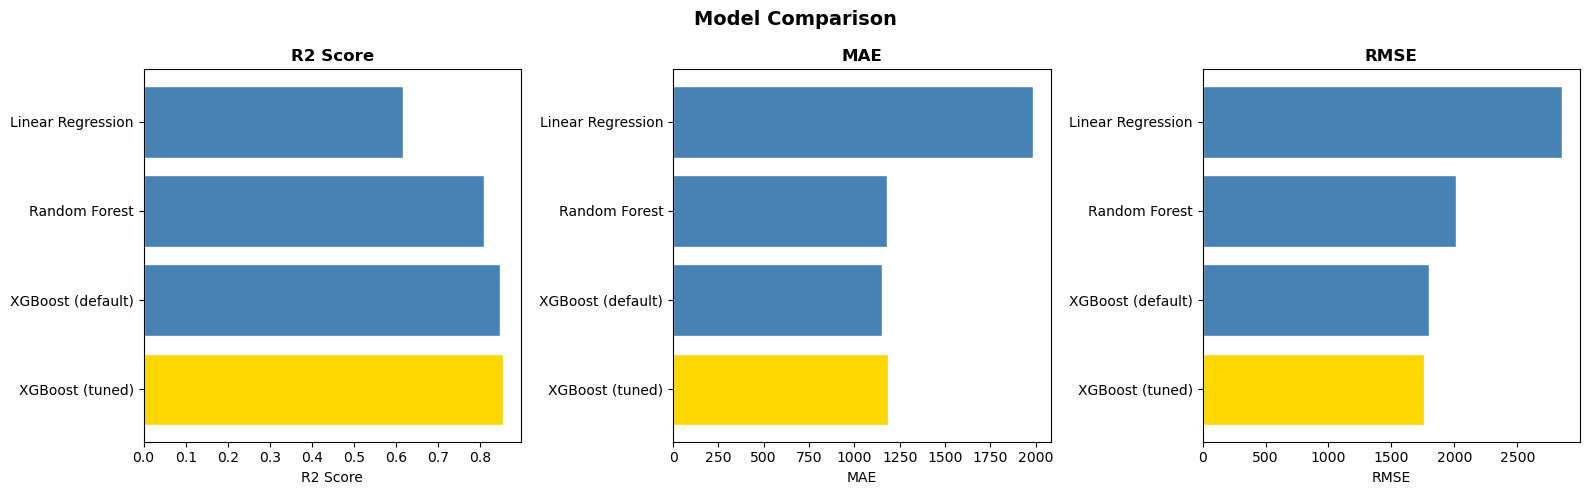

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['R2 Score', 'MAE', 'RMSE']
for i, metric in enumerate(metrics):
    colors = ['gold' if j == 0 else 'steelblue' for j in range(len(results_df))]
    axes[i].barh(results_df['Model'], results_df[metric], 
                 color=colors, edgecolor='white')
    axes[i].set_title(f'{metric}', fontweight='bold')
    axes[i].set_xlabel(metric)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Best Model: XGBoost (Tuned)

- Highest R² score of 0.8538 — explains 85% of 
  price variation
- Lowest RMSE of 1,758 INR — best at minimizing 
  large prediction errors
- MAE of 1,186 INR means predictions are on average 
  within 1,186 INR of actual price
- Linear Regression was weakest — flight pricing is 
  non-linear which tree based models handle better
- XGBoost selected for production due to best overall 
  performance across all metrics

**Future Improvements:**
- More exhaustive hyperparameter tuning could push 
  R² higher
- Collecting more recent flight data would improve 
  model generalization
- Removing Jet Airways Business outliers could improve 
  predictions for economy flights

## 7.Challenges Faced & Solutions

### Challenge 1: Heavy Feature Engineering Required
**Problem:** Almost all features were in text/string format 
— Date_of_Journey, Dep_Time, Arrival_Time, Duration and 
Total_Stops all needed conversion before modelling.

**Solution:** Extracted day and month from dates, extracted 
hour and minute from times, converted duration from "2h 30m" 
format to total minutes, and mapped Total_Stops from text 
to numeric values.

---

### Challenge 2: Duration Conversion Error
**Problem:** Some flights had duration in only hours with 
no minutes (e.g. "2h") — after string replacement this 
became "2:" causing a ValueError during conversion.

**Solution:** Added a check in the conversion function to 
handle empty minute values and default them to 0.

---

### Challenge 3: Linear Regression Underperformance
**Problem:** Linear Regression achieved only R² of 0.6150 
— flight prices have complex non-linear relationships that 
a linear model cannot capture.

**Solution:** Switched to tree based models — Random Forest 
improved R² to 0.8085 and XGBoost further improved to 
0.8538, confirming that non-linear models are better suited 
for flight price prediction.

---

### Possible Future Improvements:
- Collect more recent flight data to improve generalization
- Explore more advanced feature engineering such as 
  extracting day of week or holiday season flags
- More exhaustive hyperparameter tuning with larger 
  search space